In [1]:
!pip install -q transformers torchaudio

import os
import torch
import torch.nn as nn
import torch.optim as optim
import torchaudio.transforms as T
import librosa
import numpy as np
import glob
import time
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from transformers import ASTFeatureExtractor, ASTForAudioClassification
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo in uso: {device}")

Dispositivo in uso: cuda


In [2]:
# ==========================================================
# 2. PREPROCESSING ORIGINALE (DA MANTENERE)
# Questa parte serve a generare i file .pt necessari
# ==========================================================

def add_white_noise(data):
    noise_amp = 0.05 * np.random.uniform() * np.max(data)
    return data + noise_amp * np.random.normal(size=data.shape[0])

def pitch_shift(data, sampling_rate):
    return librosa.effects.pitch_shift(data, sr=sampling_rate, n_steps=np.random.uniform(-2, 2))

def speed_change(data):
    return librosa.effects.time_stretch(data, rate=np.random.uniform(0.8, 1.2))

# Funzione per processare e salvare i dati (adattata dal tuo file)
def process_and_save_data(base_path, output_path):
    if not os.path.exists(output_path):
        os.makedirs(output_path)
        os.makedirs(os.path.join(output_path, 'train'))
        os.makedirs(os.path.join(output_path, 'val'))
        os.makedirs(os.path.join(output_path, 'test'))
    
    # Lista di tutti i file audio (Assicurati che il percorso sia corretto)
    file_list = glob.glob(os.path.join(base_path, "Actor_*/*.wav"))
    
    if len(file_list) == 0:
        print("ERRORE: Nessun file .wav trovato. Controlla il percorso del dataset!")
        return

    print(f"Inizio preprocessing di {len(file_list)} file...")
    
    # Speaker-independent split (Richiesto dal progetto)
    # Esempio: Attori 1-20 Train, 21-22 Val, 23-24 Test
    for file_path in file_list:
        file_name = os.path.basename(file_path)
        parts = file_name.split('-')
        emotion = int(parts[2]) - 1 # Label 0-7
        actor_id = int(parts[6].split('.')[0])
        
        # Caricamento e normalizzazione
        y, sr = librosa.load(file_path, sr=16000)
        y, _ = librosa.effects.trim(y)
        
        # Padding/Truncate a 3 secondi (Standard per audio classification)
        target_len = 16000 * 3
        if len(y) < target_len:
            y = np.pad(y, (0, target_len - len(y)))
        else:
            y = y[:target_len]
            
        # Decisione della cartella di destinazione
        if actor_id <= 19: subfolder = 'train'
        elif actor_id <= 21: subfolder = 'val'
        else: subfolder = 'test'
        
        save_name = f"actor_{actor_id}_{file_name}.pt"
        # Salvataggio: audio grezzo, sample rate, label, id attore
        torch.save((y, sr, emotion, actor_id), os.path.join(output_path, subfolder, save_name))

# ESECUZIONE PREPROCESSING (Cambia il path con quello del tuo dataset RAVDESS su Kaggle)
RAVDESS_INPUT_PATH = '/kaggle/input/datasets/uwrfkaggler/ravdess-emotional-speech-audio'
PROCESSED_DATA_PATH = '/kaggle/working/processed_data'

# Decommenta la riga sotto se devi rigenerare i file .pt
process_and_save_data(RAVDESS_INPUT_PATH, PROCESSED_DATA_PATH)

Inizio preprocessing di 1440 file...


In [3]:
# ==========================================================
# 3. NUOVA PIPELINE DATASET (AST + SPECAUGMENT)
# ==========================================================
feature_extractor = ASTFeatureExtractor.from_pretrained("MIT/ast-finetuned-audioset-10-10-0.4593")

class AST_RavdessDataset(Dataset):
    def __init__(self, folder_path, is_train=False):
        self.file_paths = glob.glob(os.path.join(folder_path, "*.pt"))
        self.is_train = is_train
        
        # SpecAugment (Solo per Training)
        self.freq_mask = T.FrequencyMasking(freq_mask_param=15)
        self.time_mask = T.TimeMasking(time_mask_param=35)

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        file_to_load = self.file_paths[idx]
        wav_np, sample_rate, emotion_label, speaker_id = torch.load(file_to_load, weights_only=False)
        
        # Trasformazione in Spettrogramma per AST
        inputs = feature_extractor(wav_np, sampling_rate=16000, return_tensors="pt")
        spec = inputs.input_values.squeeze(0) # [Time, Freq]
        
        if self.is_train:
            spec = spec.transpose(0, 1) # [Freq, Time]
            spec = self.freq_mask(spec)
            spec = self.time_mask(spec)
            spec = spec.transpose(0, 1)
            
        return spec, torch.tensor(emotion_label, dtype=torch.long)

preprocessor_config.json:   0%|          | 0.00/297 [00:00<?, ?B/s]

In [4]:
# Inizializzazione Dataloader
train_loader = DataLoader(AST_RavdessDataset(os.path.join(PROCESSED_DATA_PATH, 'train'), is_train=True), batch_size=16, shuffle=True)
val_loader   = DataLoader(AST_RavdessDataset(os.path.join(PROCESSED_DATA_PATH, 'val')), batch_size=16, shuffle=False)
test_loader  = DataLoader(AST_RavdessDataset(os.path.join(PROCESSED_DATA_PATH, 'test')), batch_size=16, shuffle=False)

In [5]:
# ==========================================================
# 4. MODELLO AST E TRANSFER LEARNING
# ==========================================================

# Caricamento Modello
model = ASTForAudioClassification.from_pretrained(
    "MIT/ast-finetuned-audioset-10-10-0.4593", 
    num_labels=8, 
    ignore_mismatched_sizes=True 
).to(device)

# --- FASE 1: FEATURE EXTRACTION (Freeze backbone) ---
for param in model.audio_spectrogram_transformer.parameters():
    param.requires_grad = False

optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

# --- FUNZIONE PER FASE 2: PROGRESSIVE UNFREEZING ---
def start_fine_tuning(model, blocks=4):
    for param in model.audio_spectrogram_transformer.encoder.layer[-blocks:].parameters():
        param.requires_grad = True
    for param in model.audio_spectrogram_transformer.layernorm.parameters():
        param.requires_grad = True
    return optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-5)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

ASTForAudioClassification LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                     | Status   |                                                                                       
------------------------+----------+---------------------------------------------------------------------------------------
classifier.dense.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([527]) vs model:torch.Size([8])          
classifier.dense.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([527, 768]) vs model:torch.Size([8, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


In [6]:
# ==========================================================
# 5. TRAINING LOOP (NUOVO FORMATO PER AST)
# ==========================================================

def run_epoch(model, loader, optimizer, criterion, is_train=True):
    model.train() if is_train else model.eval()
    total_loss, correct = 0, 0
    
    for specs, labels in loader:
        specs, labels = specs.to(device), labels.to(device)
        
        if is_train:
            optimizer.zero_grad()
            outputs = model(specs)
            loss = criterion(outputs.logits, labels)
            loss.backward()
            optimizer.step()
        else:
            with torch.no_grad():
                outputs = model(specs)
                loss = criterion(outputs.logits, labels)
        
        total_loss += loss.item()
        preds = outputs.logits.argmax(dim=-1)
        correct += preds.eq(labels).sum().item()
        
    return total_loss / len(loader), correct / len(loader.dataset)

# ESECUZIONE FASE 1
print("--- FASE 1: TRAINING HEAD ---")
for epoch in range(5):
    t_loss, t_acc = run_epoch(model, train_loader, optimizer, criterion)
    v_loss, v_acc = run_epoch(model, val_loader, None, criterion, is_train=False)
    print(f"Epoch {epoch+1}: Train Acc {t_acc:.2%}, Val Acc {v_acc:.2%}")

# ESECUZIONE FASE 2
print("\n--- FASE 2: FINE-TUNING TRANSFORMER ---")
optimizer = start_fine_tuning(model, blocks=4)
for epoch in range(10):
    t_loss, t_acc = run_epoch(model, train_loader, optimizer, criterion)
    v_loss, v_acc = run_epoch(model, val_loader, None, criterion, is_train=False)
    print(f"Epoch {epoch+1}: Train Acc {t_acc:.2%}, Val Acc {v_acc:.2%}")

--- FASE 1: TRAINING HEAD ---
Epoch 1: Train Acc 24.12%, Val Acc 24.17%
Epoch 2: Train Acc 34.91%, Val Acc 44.17%
Epoch 3: Train Acc 40.70%, Val Acc 53.33%
Epoch 4: Train Acc 45.44%, Val Acc 57.50%
Epoch 5: Train Acc 46.32%, Val Acc 55.00%

--- FASE 2: FINE-TUNING TRANSFORMER ---
Epoch 1: Train Acc 51.14%, Val Acc 45.83%
Epoch 2: Train Acc 54.56%, Val Acc 52.50%
Epoch 3: Train Acc 60.88%, Val Acc 60.00%
Epoch 4: Train Acc 65.53%, Val Acc 55.00%
Epoch 5: Train Acc 67.81%, Val Acc 62.50%
Epoch 6: Train Acc 71.84%, Val Acc 61.67%
Epoch 7: Train Acc 76.23%, Val Acc 50.83%
Epoch 8: Train Acc 79.91%, Val Acc 59.17%
Epoch 9: Train Acc 81.93%, Val Acc 55.83%
Epoch 10: Train Acc 83.95%, Val Acc 60.00%



Accuracy Finale: 57.78%


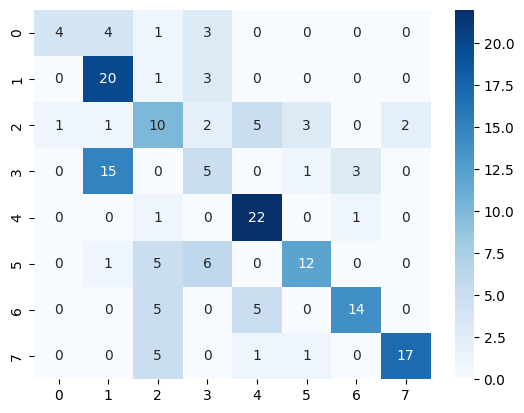

In [7]:
# ==========================================================
# 6. VALUTAZIONE FINALE
# ==========================================================
def final_eval(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for specs, labels in loader:
            outputs = model(specs.to(device))
            all_preds.extend(outputs.logits.argmax(dim=-1).cpu().numpy())
            all_labels.extend(labels.numpy())
    
    print(f"\nAccuracy Finale: {accuracy_score(all_labels, all_preds):.2%}")
    cm = confusion_matrix(all_labels, all_preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.show()

final_eval(model, test_loader)